# Synthese spectrale a phases aleatoires

Ce notebook illustre les trois etapes de la methode de Shinozuka (1972) pour generer un signal vibratoire aleatoire conforme a une DSP cible fictive, puis montre que la somme directe des cosinus et la methode IFFT x N donnent le meme resultat.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({'font.size': 10, 'figure.dpi': 100})

## Etape 1 — Discretiser la DSP cible

La DSP cible fictive est un plateau constant :

$$S(f) = S_0 = 0{,}01 \text{ g}^2/\text{Hz} \quad \text{pour } f \in [2, 20] \text{ Hz}$$

On choisit une duree $T = 4$ s et une frequence d'echantillonnage $f_e = 500$ Hz, ce qui donne :

- $N = T \times f_e = 2000$ points
- $\Delta f = 1/T = 0{,}25$ Hz (resolution frequentielle)
- Grille : $f_k = k \cdot \Delta f$, $k = 1, \ldots, N/2 - 1$

Pour chaque $f_k$, on evalua $S(f_k)$ par simple seuillage (cas du plateau rectangulaire).

In [2]:
# Parametres communs (identiques au code gen_shinozuka_etapes.py)
T      = 4.0
fs     = 500.0
N      = int(T * fs)   # 2000
df     = 1.0 / T       # 0.25 Hz

S0     = 0.01          # g^2/Hz
f_low  = 2.0           # Hz
f_high = 20.0          # Hz

# Grille frequentielle et DSP discretisee
k      = np.arange(1, N // 2)       # k = 1 ... 999
f_k    = k * df                     # f_k en Hz
S_fk   = np.where((f_k >= f_low) & (f_k <= f_high), S0, 0.0)

n_comp = int((f_high - f_low) / df) + 1   # 73 composantes dans la bande
print(f"N = {N} points    Delta_f = {df} Hz    f_max = {fs/2:.0f} Hz")
print(f"Composantes dans la bande : {n_comp}  (k = {int(f_low/df)} a {int(f_high/df)})")

N = 2000 points    Delta_f = 0.25 Hz    f_max = 250 Hz
Composantes dans la bande : 73  (k = 8 a 80)


In [3]:
# Affichage S(f_k) pour les indices autour du front a 2 Hz et 20 Hz
print(f"{'k':>4}  {'f_k (Hz)':>8}  {'S(f_k) (g^2/Hz)':>18}")
print("-" * 36)
for ki in [6, 7, 8, 9, 10, 79, 80, 81]:
    s = S_fk[ki - 1]
    print(f"{ki:>4}  {ki*df:>8.2f}  {s:>18.4f}")

   k  f_k (Hz)     S(f_k) (g^2/Hz)
------------------------------------
   6      1.50              0.0000
   7      1.75              0.0000
   8      2.00              0.0100
   9      2.25              0.0100
  10      2.50              0.0100
  79     19.75              0.0100
  80     20.00              0.0100
  81     20.25              0.0000


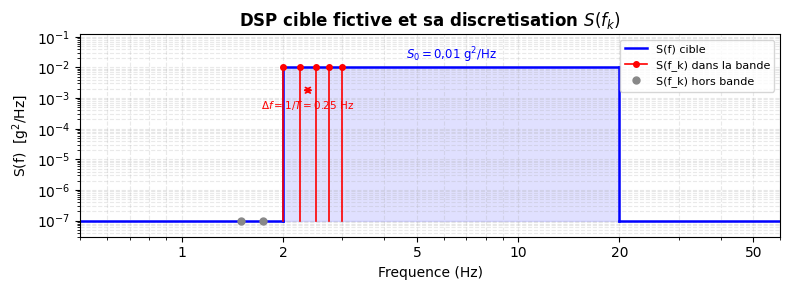

In [4]:
# Trace de la DSP cible et des raies discretes
fig, ax = plt.subplots(figsize=(8, 3))

S_floor = 1e-7
ax.loglog([0.5, f_low],    [S_floor, S_floor], 'b-', lw=1.8)
ax.loglog([f_low, f_low],  [S_floor, S0],      'b-', lw=1.8)
ax.loglog([f_low, f_high], [S0, S0],           'b-', lw=1.8, label='S(f) cible')
ax.loglog([f_high, f_high],[S0, S_floor],      'b-', lw=1.8)
ax.loglog([f_high, 60],    [S_floor, S_floor], 'b-', lw=1.8)
ax.fill_between([f_low, f_high], [S_floor, S_floor], [S0, S0], alpha=0.12, color='blue')

for ki in [6, 7]:
    ax.plot(ki * df, S_floor, 'o', color='#888888', ms=5)

for ki in range(8, 13):
    ax.plot([ki*df, ki*df], [S_floor, S0], 'r-', lw=1.2)
    ax.plot(ki * df, S0, 'ro', ms=4)

ax.text(np.sqrt(f_low * f_high), S0 * 1.8, r'$S_0 = 0{,}01$ g$^2$/Hz',
        ha='center', fontsize=8.5, color='blue')

# Fleche Delta_f entre k=9 et k=10
f_a, f_b, y_df = 9*df, 10*df, S0 * 0.18
ax.annotate('', xy=(f_b, y_df), xytext=(f_a, y_df),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1.2))
ax.text(np.sqrt(f_a*f_b), y_df*0.5, f'$\\Delta f = 1/T = {df}$ Hz',
        ha='center', va='top', fontsize=7.5, color='red')

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='blue', lw=1.8, label='S(f) cible'),
    Line2D([0],[0], color='red',  lw=1.2, marker='o', ms=4, label='S(f_k) dans la bande'),
    Line2D([0],[0], color='#888', lw=0,   marker='o', ms=5, label='S(f_k) hors bande'),
], fontsize=8)
ax.set_xlabel('Frequence (Hz)'); ax.set_ylabel('S(f)  [g$^2$/Hz]')
ax.set_title('DSP cible fictive et sa discretisation $S(f_k)$', fontweight='bold')
ax.set_xlim([0.5, 60]); ax.set_ylim([S_floor*0.3, 0.12])
ax.set_xticks([1, 2, 5, 10, 20, 50])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.grid(True, which='both', ls='--', alpha=0.28)
plt.tight_layout()
plt.show()

## Etape 2 — Calculer les coefficients spectraux complexes $\hat{A}_k$

Pour chaque frequence $f_k$ :

$$A_k = \sqrt{\frac{S(f_k)\cdot\Delta f}{2}}$$

Le facteur $1/2$ est la convention du spectre bilateral : on ne met qu'une moitie de l'energie sur les frequences positives ; l'autre moitie sera portee par le conjugue $\hat{A}_k^*$ a la frequence negative $-f_k$.

La phase $\varphi_k \sim \mathcal{U}(0, 2\pi)$ est tiree independamment pour chaque $k$.

$$\hat{A}_k = A_k \, e^{j\varphi_k}$$

In [5]:
# Graine fixe pour reproductibilite
rng    = np.random.default_rng(42)
phi_k  = rng.uniform(0, 2*np.pi, len(k))

A_k    = np.sqrt(S_fk * df / 2)          # amplitude (spectre bilateral)
Ahat_k = A_k * np.exp(1j * phi_k)        # coefficient spectral complexe

A_band = np.sqrt(S0 * df / 2)
print(f"A_k dans la bande [2, 20 Hz] = {A_band:.5f} g")
print(f"2 * A_k = sqrt(2 * S0 * Delta_f) = {2*A_band:.5f} g  (amplitude Shinozuka)")
print(f"Composantes non nulles : {np.sum(A_k > 0)}")

A_k dans la bande [2, 20 Hz] = 0.03536 g
2 * A_k = sqrt(2 * S0 * Delta_f) = 0.07071 g  (amplitude Shinozuka)
Composantes non nulles : 73


In [ ]:
# Plan complexe : 4 premiers phaseurs non nuls (k = 8, 9, 10, 11)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
couleurs = ['#cc2222', '#2255cc', '#22aa44', '#dd8800']

for i, ki in enumerate([8, 9, 10, 11]):
    A_val  = A_k[ki - 1]
    ph_val = phi_k[ki - 1]
    re, im = A_val * np.cos(ph_val), A_val * np.sin(ph_val)
    ax.annotate('', xy=(re, im), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=couleurs[i], lw=1.8))
    ax.plot(re, im, 'o', color=couleurs[i], ms=5)
    decal = 0.005
    ax.text(re + decal, im + decal,
            f'$\\hat{{A}}_{{{ki}}}$\n$f = {ki*df:.2f}$ Hz',
            fontsize=8, color=couleurs[i])

theta = np.linspace(0, 2*np.pi, 300)
ax.plot(A_band * np.cos(theta), A_band * np.sin(theta), '--',
        color='gray', lw=0.9, alpha=0.6,
        label=f'$|\\hat{{A}}_k| = {A_band:.4f}$ g')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
lim = A_band * 1.7
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim])
ax.set_aspect('equal')
ax.set_xlabel('Partie reelle [g]'); ax.set_ylabel('Partie imaginaire [g]')
ax.set_title(r'Plan complexe — phaseurs $\hat{A}_k$ (k = 8 a 11)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Etape 3a — Creer le signal par somme directe (O(N$^2$))

La formule de Shinozuka s'ecrit :

$$x(t) = \sum_{k=1}^{N_\text{freq}} \sqrt{2\,S(f_k)\,\Delta f}\;\cos(2\pi f_k t + \varphi_k)
= \sum_k 2\,A_k\,\cos(2\pi f_k t + \varphi_k)$$

On evalue cette somme en chaque point de temps $t_n = n/f_e$, $n = 0, \ldots, N-1$.

Avec $N_\text{freq}$ composantes et $N$ points de temps, le cout est **O($N_\text{freq} \times N$)**.
Pour notre DSP bornee, $N_\text{freq} \ll N$, mais pour une simulation longue (T = 600 s),
$N_\text{freq} \approx 10\,800$ et $N = 300\,000$ : la matrice contiendrait 3,2 milliards d'elements.

In [ ]:
t_n = np.arange(N) / fs   # vecteur temps (2000 points)

# Conserver uniquement les composantes non nulles (dans la bande)
mask    = A_k > 0
f_act   = f_k[mask]      # (73,)
A_act   = A_k[mask]
phi_act = phi_k[mask]

print(f"Composantes actives : {mask.sum()}  (k = {int(f_low/df)} a {int(f_high/df)})")
print(f"Taille de la matrice phases : {mask.sum()} x {N} = {mask.sum()*N:,} elements")

t0 = time.perf_counter()

# Matrice de phases : (N_freq, N_samples)
phases   = 2*np.pi * f_act[:, None] * t_n[None, :] + phi_act[:, None]
x_direct = (2 * A_act[:, None] * np.cos(phases)).sum(axis=0)

t1 = time.perf_counter()
duree_direct = t1 - t0

grms_th  = np.sqrt(S0 * (f_high - f_low))
grms_sim = np.std(x_direct)
print(f"\nDuree somme directe : {duree_direct*1000:.1f} ms")
print(f"g_rms simule  = {grms_sim:.4f} g")
print(f"g_rms theorique = {grms_th:.4f} g")

## Etape 3b — Creer le signal par IFFT x N (O(N log N))

On construit le spectre **bilateral hermitien** de taille N :

$$\text{ACC}[k] = \begin{cases} 0 & k=0 \\ \hat{A}_k & k = 1, \ldots, N/2-1 \\ 0 & k = N/2 \\ \hat{A}_{N-k}^* & k = N/2+1, \ldots, N-1 \end{cases}$$

Puis on applique l'IFFT de NumPy (convention : divise par N) et on multiplie par N pour retrouver la somme.

**Pourquoi cela revient a la somme de Shinozuka ?**
Pour chaque $k$ dans la bande, la paire hermitienne $(\hat{A}_k, \hat{A}_k^*)$ contribue dans le domaine temporel :

$$\hat{A}_k\,e^{j2\pi f_k t} + \hat{A}_k^*\,e^{-j2\pi f_k t}
= 2A_k\cos(2\pi f_k t + \varphi_k)$$

par la formule d'Euler ($e^{j\theta} + e^{-j\theta} = 2\cos\theta$).
En sommant sur tous les $k$, on retrouve exactement la formule de Shinozuka.

Le gain de complexite vient de l'algorithme de Cooley-Tukey : l'IFFT de N points se decompose recursivement en 2 IFFT de N/2 points en exploitant la periodicite des exponentielles complexes. La recurrence $T(N) = 2T(N/2) + O(N)$ donne $T(N) = O(N \log_2 N)$.

In [ ]:
t0 = time.perf_counter()

# Spectre bilateral hermitien de taille N = 2000
ACC_full = np.concatenate([[0], Ahat_k, [0], np.conj(Ahat_k[::-1])])
# Verification : taille = 1 + 999 + 1 + 999 = 2000 = N

# IFFT de NumPy divise par N => on multiplie par N pour avoir la somme
x_ifft = np.real(np.fft.ifft(ACC_full)) * N

t1 = time.perf_counter()
duree_ifft = t1 - t0

print(f"Taille de ACC_full : {len(ACC_full)} (= N = {N})")
print(f"Duree IFFT x N     : {duree_ifft*1e6:.0f} µs")
print(f"Duree somme directe: {duree_direct*1000:.1f} ms")
print(f"Rapport de vitesse : {duree_direct/duree_ifft:.0f}x")
print(f"\ng_rms IFFT  = {np.std(x_ifft):.4f} g  (identique : {np.std(x_ifft):.4f} vs {grms_sim:.4f})")

## Comparaison des deux methodes

Les deux signaux doivent etre rigoureusement identiques aux erreurs d'arrondi de virgule flottante pres (de l'ordre de $10^{-13}$ g, soit 10 ordres de grandeur en dessous du signal).

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=False)

n_show = int(fs * 1.5)
axes[0].plot(t_n[:n_show], x_direct[:n_show], 'r-',  lw=0.9, label='Somme directe Shinozuka')
axes[0].plot(t_n[:n_show], x_ifft[:n_show],   'b--', lw=0.9, alpha=0.7, label='IFFT x N')
axes[0].set_ylabel('x(t) [g]')
axes[0].set_title('Les deux methodes donnent le meme signal', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, ls='--', alpha=0.3)

diff = x_direct - x_ifft
axes[1].plot(t_n, diff, 'k-', lw=0.5)
axes[1].set_xlabel('t (s)')
axes[1].set_ylabel('Ecart [g]')
axes[1].set_title(f'Difference : erreur numerique max = {np.abs(diff).max():.2e} g  (virgule flottante 64 bits)')
axes[1].grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Difference max : {np.abs(diff).max():.2e} g")
print(f"Difference rms : {np.std(diff):.2e} g")

## Verification — Gaussianite et g_rms

La somme de $N_\text{freq}$ cosinus a phases uniformes independantes converge vers une loi normale $\mathcal{N}(0, g_\text{rms}^2)$ par le theoreme central limite.

La valeur theorique de l'ecart-type est :

$$g_\text{rms} = \sqrt{S_0 \cdot (f_\text{max} - f_\text{min})} = \sqrt{0{,}01 \times 18} \approx 0{,}424 \text{ g}$$

L'histogramme normalise (densite) doit epouser la courbe gaussienne theorique.

**Construction de l'histogramme :** on divise la plage $[-4\,g_\text{rms}, +4\,g_\text{rms}]$ en $B = 50$ intervalles de largeur $h$.  
Pour chaque intervalle $b$, on compte $n_b$ echantillons et on calcule la densite $d_b = n_b / (N \cdot h)$.  
L'aire totale des barres vaut 1, ce qui permet la comparaison directe avec la densite de probabilite theorique.

In [ ]:
grms_sim_ifft = np.std(x_ifft)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Signal
ax1.plot(t_n[:n_show], x_ifft[:n_show], color='#cc2222', lw=0.7)
ax1.axhline( grms_th, color='gray', ls='--', lw=1.3,
             label=f'$\\pm g_{{rms}} = {grms_th:.3f}$ g')
ax1.axhline(-grms_th, color='gray', ls='--', lw=1.3)
ax1.set_xlabel('t (s)'); ax1.set_ylabel('x(t) [g]')
ax1.set_title('Signal x(t) (extrait 1,5 s)', fontweight='bold')
ax1.legend(fontsize=8); ax1.grid(True, ls='--', alpha=0.3)

# Histogramme
bins = np.linspace(-4*grms_th, 4*grms_th, 51)
ax2.hist(x_ifft, bins=bins, density=True, color='#cc2222', alpha=0.55,
         edgecolor='none', label='x(t) — histogramme')

xx    = np.linspace(-4*grms_th, 4*grms_th, 500)
gauss = np.exp(-xx**2 / (2*grms_th**2)) / (grms_th * np.sqrt(2*np.pi))
ax2.plot(xx, gauss, 'b-', lw=1.8,
         label=r'$\mathcal{N}(0,\,g_{\rm rms}^2)$ theorique')
ax2.axvline( grms_th, color='gray', ls='--', lw=1.0)
ax2.axvline(-grms_th, color='gray', ls='--', lw=1.0)
ax2.set_xlabel('x [g]'); ax2.set_ylabel('Densite de probabilite')
ax2.set_title(
    f'Distribution de x(t)\n$g_{{rms}}$ sim = {grms_sim_ifft:.4f} g  |  theorique = {grms_th:.4f} g',
    fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"g_rms simule    = {grms_sim_ifft:.4f} g")
print(f"g_rms theorique = {grms_th:.4f} g")
print(f"Ecart relatif   = {abs(grms_sim_ifft - grms_th)/grms_th * 100:.2f} %")
print()
print("Note : l'ecart est faible car T = 4 s donne deja 2000 points.")
print("Avec T = 600 s (simulation reelle), l'histogramme serait quasiment parfait.")

## Bilan

| | Somme directe | IFFT x N |
|---|---|---|
| Complexite | O(N_freq x N) | O(N log N) |
| Formule | $\sum_k 2A_k\cos(2\pi f_k t + \varphi_k)$ | spectre bilateral hermitien + IFFT |
| Resultat | identique | identique |
| Interet pedagogique | lisibilite directe de la formule | comprendre la symetrie hermitienne et Euler |

Pour T = 4 s (N = 2 000) et une bande [2, 20 Hz] (73 composantes), la difference de temps est deja visible.  
Pour T = 600 s (N = 300 000) et une bande [2, 200 Hz] (N_freq ~ 118 000), la somme directe necessite 35 milliards d'operations et prendrait plusieurs heures ; l'IFFT reste en dessous de la seconde.